# EDA de PM2.5 — Entrega 1

## 1. Objetivo

Este notebook sigue el orden trabajado en los ejemplos del curso: cargar los datos, entender qué representan filas y columnas, revisar `head`, `shape`, `dtypes`, `info` y `describe`, evaluar calidad y explicar cada resultado. Su objetivo es respaldar la caracterización y los insights exigidos en la Entrega 1; aquí no se entrenan modelos.

## 2. Fuente y reproducibilidad

Los archivos provienen del dataset oficial **Histórico de Material Particulado - PM2.5** de SIATA, DOI `10.83041/AUWZWT`, versión 4.0 consultada el 14 de septiembre de 2026. Se descargan con `python scripts/download_pm25_dataset.py --all`; los datos crudos no se versionan en Git. El loader utilizado abajo solo automatiza tres tareas repetitivas: detectar el separador, convertir `fecha_hora` y comprobar que las mediciones sean numéricas.

## 3. Carga de datos

Se importan únicamente las librerías necesarias y se localizan los archivos desde la raíz del proyecto para que el notebook funcione tanto desde Jupyter como desde el repositorio.

In [1]:
from collections import Counter
from pathlib import Path
import io
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_pm25_files, read_pm25_file

DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'pm25'
files = sorted(DATA_DIR.glob('Estaciones_PM2.5_*.tab'))
len(files), files[0].name, files[-1].name

(162, 'Estaciones_PM2.5_2013_01.tab', 'Estaciones_PM2.5_2026_06.tab')

## 4. Estructura de un archivo mensual

Primero se examina enero de 2013. El loader detecta codificación y delimitador; no se supone que `.tab` implique tabuladores. El archivo original de este mes está separado por comas.

In [2]:
sample = read_pm25_file(files[0])
display(sample.head())
display(sample.tail())
print('shape:', sample.shape)
print('columns:', sample.columns.tolist())
print('dtypes:')
display(sample.dtypes.to_frame('dtype'))
buffer = io.StringIO()
sample.info(buf=buffer)
print(buffer.getvalue())
display(sample.describe(include='all'))

,fecha_hora,MED-UNNV,CEN-TRAF,ITA-CJUS,ITA-CONC,CAL-LASA
0,2013-01-01 00:00:00,69.0,77.0,NaN,121.0,NaN
1,2013-01-01 01:00:00,80.0,78.0,NaN,62.0,NaN
2,2013-01-01 02:00:00,55.0,59.0,NaN,86.0,NaN
3,2013-01-01 03:00:00,50.0,39.0,NaN,74.0,NaN
4,2013-01-01 04:00:00,34.0,34.0,NaN,44.0,NaN


,fecha_hora,MED-UNNV,CEN-TRAF,ITA-CJUS,ITA-CONC,CAL-LASA
739,2013-01-31 19:00:00,37.0,48.0,NaN,31.0,29.0
740,2013-01-31 20:00:00,35.0,40.0,NaN,28.0,38.0
741,2013-01-31 21:00:00,36.0,32.0,NaN,24.0,33.0
742,2013-01-31 22:00:00,31.0,34.0,NaN,22.0,39.0
743,2013-01-31 23:00:00,31.0,49.0,NaN,33.0,31.0


shape: (744, 6)
columns: ['fecha_hora', 'MED-UNNV', 'CEN-TRAF', 'ITA-CJUS', 'ITA-CONC', 'CAL-LASA']
dtypes:


,dtype
fecha_hora,datetime64[us]
MED-UNNV,float64
CEN-TRAF,float64
ITA-CJUS,float64
ITA-CONC,float64
CAL-LASA,float64


<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha_hora  744 non-null    datetime64[us]
 1   MED-UNNV    691 non-null    float64       
 2   CEN-TRAF    733 non-null    float64       
 3   ITA-CJUS    542 non-null    float64       
 4   ITA-CONC    617 non-null    float64       
 5   CAL-LASA    440 non-null    float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 35.0 KB



,fecha_hora,MED-UNNV,CEN-TRAF,ITA-CJUS,ITA-CONC,CAL-LASA
count,744,691.000000,733.000000,542.000000,617.000000,440.000000
mean,2013-01-16 11:30:00,34.639653,38.572988,22.953875,28.071313,31.088636
min,2013-01-01 00:00:00,11.000000,0.000000,2.000000,2.000000,9.000000
25%,2013-01-08 17:45:00,28.000000,31.000000,17.000000,19.000000,25.000000
50%,2013-01-16 11:30:00,33.000000,38.000000,22.000000,27.000000,31.000000
75%,2013-01-24 05:15:00,39.000000,46.000000,27.000000,36.000000,37.000000
max,2013-01-31 23:00:00,126.000000,109.000000,64.000000,121.000000,61.000000
std,NaN,11.183274,13.913047,9.656374,13.223163,8.990446


Cada fila representa una hora y cada columna distinta de `fecha_hora` contiene el promedio horario de PM2.5 de una estación, en µg/m³. Por ejemplo, `MED-UNNV` es Universidad Nacional, Núcleo El Volador; `CEN-TRAF` es Estación Tráfico Centro; `ITA-CJUS` es Casa de Justicia de Itagüí. La tabla original está en formato ancho y más adelante se reorganiza para que cada fila represente una estación-hora.

In [3]:
sample_stations = sample.columns.drop('fecha_hora')
sample_quality = pd.DataFrame({
    'missing': sample[sample_stations].isna().sum(),
    'missing_pct': sample[sample_stations].isna().mean().mul(100),
    'min': sample[sample_stations].min(),
    'max': sample[sample_stations].max(),
})
display(sample_quality.round(2))
print('Filas duplicadas:', sample.duplicated().sum())
print('Fechas duplicadas:', sample['fecha_hora'].duplicated().sum())
print('Fechas inválidas:', sample['fecha_hora'].isna().sum())
print('Intervalos temporales:')
display(sample['fecha_hora'].sort_values().diff().value_counts())

,missing,missing_pct,min,max
MED-UNNV,53,7.12,11.0,126.0
CEN-TRAF,11,1.48,0.0,109.0
ITA-CJUS,202,27.15,2.0,64.0
ITA-CONC,127,17.07,2.0,121.0
CAL-LASA,304,40.86,9.0,61.0


Filas duplicadas: 0
Fechas duplicadas: 0
Fechas inválidas: 0
Intervalos temporales:


fecha_hora
0 days 01:00:00    743
Name: count, dtype: int64

### 4.1 Consolidación y compatibilidad histórica

Los cambios en la red hacen que no todos los meses tengan las mismas estaciones. El loader flexible conserva la unión de columnas y marca con `NaN` los periodos en que una estación no aparece. Esto no debe confundirse con falla del sensor durante su periodo activo.

In [4]:
schemas = Counter()
for file in files:
    monthly = read_pm25_file(file)
    schemas[tuple(monthly.columns.drop('fecha_hora'))] += 1

data = load_pm25_files(DATA_DIR, add_source_file=True)
station_columns = [c for c in data.columns if c not in {'fecha_hora', 'source_file'}]
print('Archivos:', len(files))
print('Variantes de schema:', len(schemas))
print('Shape consolidado:', data.shape)
print('Estaciones históricas:', len(station_columns))
print('Rango:', data['fecha_hora'].min(), 'a', data['fecha_hora'].max())

Archivos: 162
Variantes de schema: 30
Shape consolidado: (118296, 35)
Estaciones históricas: 33
Rango: 2013-01-01 00:00:00 a 2026-06-30 23:00:00


In [5]:
values = data[station_columns]
expected_hours = pd.date_range(data['fecha_hora'].min(), data['fecha_hora'].max(), freq='h')
quality_summary = pd.Series({
    'duplicate_rows': int(data.duplicated().sum()),
    'duplicate_timestamps': int(data['fecha_hora'].duplicated().sum()),
    'missing_global_hours': len(expected_hours.difference(data['fecha_hora'])),
    'rows_all_stations_missing': int(values.isna().all(axis=1).sum()),
    'negative_measurements': int(values.lt(0).sum().sum()),
    'zero_measurements': int(values.eq(0).sum().sum()),
    'non_null_measurements': int(values.notna().sum().sum()),
})
display(quality_summary.to_frame('value'))

,value
duplicate_rows,0
duplicate_timestamps,0
missing_global_hours,0
rows_all_stations_missing,47
negative_measurements,0
zero_measurements,5036
non_null_measurements,1879277


## 5. Calidad y cobertura por estación

La cobertura se calcula únicamente entre la primera y la última medición de cada estación. Usar como denominador todo 2013–2026 penalizaría artificialmente a estaciones instaladas después o retiradas antes.

In [6]:
coverage_rows = []
for station in station_columns:
    available = data.loc[data[station].notna(), ['fecha_hora', station]]
    first, last = available['fecha_hora'].min(), available['fecha_hora'].max()
    possible = int((last - first) / pd.Timedelta(hours=1)) + 1
    coverage_rows.append({
        'station': station,
        'non_null': len(available),
        'coverage_pct_active_period': 100 * len(available) / possible,
        'first_measurement': first,
        'last_measurement': last,
    })
coverage = pd.DataFrame(coverage_rows).set_index('station').sort_values('non_null', ascending=False)
coverage_display = coverage.copy()
coverage_display['coverage_pct_active_period'] = coverage_display['coverage_pct_active_period'].round(2)
display(coverage_display)

,non_null,coverage_pct_active_period,first_measurement,last_measurement
station,,,,
ITA-CJUS,112075,94.77,2013-01-02 12:00:00,2026-06-30 23:00:00
ITA-CONC,111485,94.24,2013-01-01 00:00:00,2026-06-30 23:00:00
CEN-TRAF,110420,93.34,2013-01-01 00:00:00,2026-06-30 23:00:00
CAL-LASA,78097,95.53,2013-01-12 23:00:00,2022-05-12 07:00:00
EST-HOSP,76013,97.39,2017-08-04 20:00:00,2026-06-30 23:00:00
COP-CVID,74263,96.52,2017-09-20 01:00:00,2026-06-30 23:00:00
MED-ARAN,73802,96.35,2017-10-04 12:00:00,2026-06-30 23:00:00
MED-BEME,73744,96.23,2017-10-02 22:00:00,2026-06-30 23:00:00
MED-ALTA,73495,94.77,2017-08-25 18:00:00,2026-06-30 23:00:00


### 5.1 Ventana de análisis

Se evalúa 2018–2025 porque son años completos y reúnen una parte estable de la red. Se conservan inicialmente las estaciones con al menos 90% de mediciones presentes en esa ventana; no se imputan valores en este paso.

In [7]:
candidate = data[data['fecha_hora'].between('2018-01-01', '2025-12-31 23:00:00')]
candidate_coverage = candidate[station_columns].notna().mean().mul(100).sort_values(ascending=False)
display(candidate_coverage[candidate_coverage >= 90].to_frame('coverage_pct').round(2))
print('Horas en la ventana:', len(candidate))
print('Estaciones con cobertura >= 90%:', int((candidate_coverage >= 90).sum()))

,coverage_pct
EST-HOSP,97.41
ITA-CJUS,96.82
COP-CVID,96.63
ENV-HOSP,96.36
MED-BEME,96.33
MED-ARAN,96.24
MED-SCRI,95.34
MED-TESO,95.33
ITA-CONC,95.32
BEL-FEVE,95.25


Horas en la ventana: 70128
Estaciones con cobertura >= 90%: 16


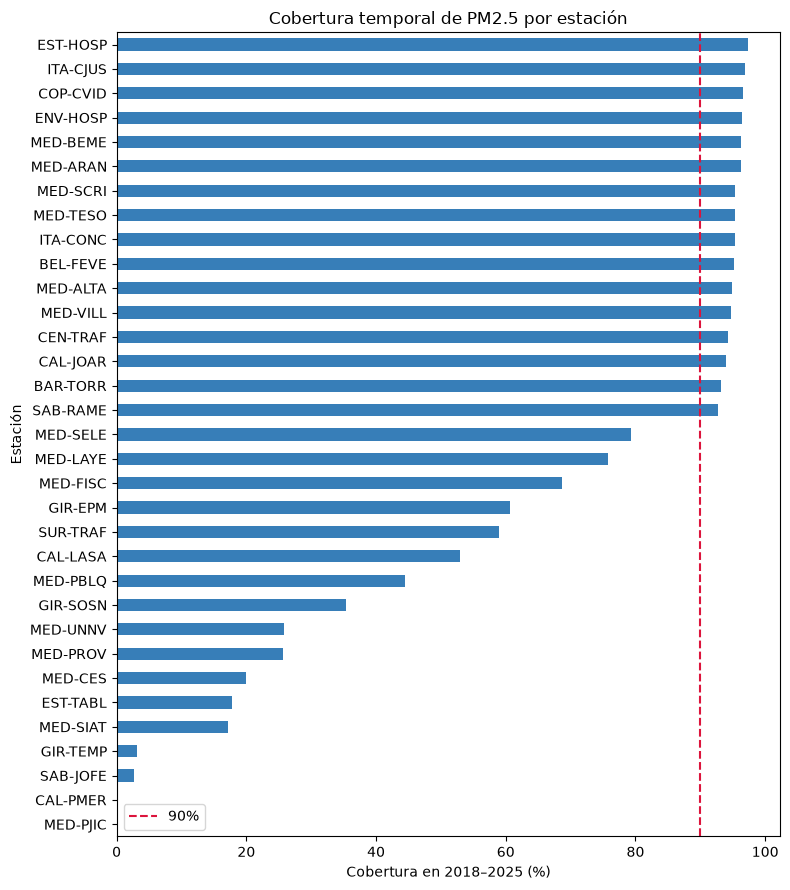

In [8]:
candidate_coverage.sort_values().plot.barh(figsize=(8, 9), color='#377eb8')
plt.axvline(90, color='crimson', linestyle='--', label='90%')
plt.xlabel('Cobertura en 2018–2025 (%)')
plt.ylabel('Estación')
plt.title('Cobertura temporal de PM2.5 por estación')
plt.legend()
plt.tight_layout()
plt.show()

La línea roja marca el criterio de 90%. Se conservaron 16 estaciones, con coberturas entre 92,67% y 97,41%. El filtro evita comparar series con periodos muy distintos y deja explícito cuánta información aporta cada estación.

## 6. Variable objetivo y tabla analítica

En formato largo, cada fila es una **estación en una hora**. `pm25` es la medición conocida en la hora `t`; `station_id` identifica dónde fue tomada y `fecha_hora` permite ordenar la serie y crear variables temporales. El target `pm25_t_plus_1` es la concentración de esa misma estación exactamente una hora después.

In [9]:
selected_stations = candidate_coverage[candidate_coverage >= 90].index.tolist()
analysis_wide = candidate[['fecha_hora', *selected_stations]].copy()
analysis_long = analysis_wide.melt(
    id_vars='fecha_hora',
    var_name='station_id',
    value_name='pm25',
).sort_values(['station_id', 'fecha_hora'])

analysis_long['hour'] = analysis_long['fecha_hora'].dt.hour
analysis_long['day_of_week'] = analysis_long['fecha_hora'].dt.dayofweek
analysis_long['month'] = analysis_long['fecha_hora'].dt.month
analysis_long['pm25_t_plus_1'] = analysis_long.groupby('station_id')['pm25'].shift(-1)
analysis_long['target_time'] = analysis_long.groupby('station_id')['fecha_hora'].shift(-1)
is_next_hour = (analysis_long['target_time'] - analysis_long['fecha_hora']) == pd.Timedelta(hours=1)
analysis_long.loc[~is_next_hour, 'pm25_t_plus_1'] = pd.NA

display(analysis_long.head())
print('Shape ancho:', analysis_wide.shape)
print('Shape largo:', analysis_long.shape)
eligible = analysis_long.dropna(subset=['pm25', 'pm25_t_plus_1']).copy()
print('Targets disponibles:', analysis_long['pm25_t_plus_1'].notna().sum())
print('Pares con predictor y target:', len(eligible))
print('Porcentaje utilizable:', round(100 * len(eligible) / len(analysis_long), 2), '%')

,fecha_hora,station_id,pm25,hour,day_of_week,month,pm25_t_plus_1,target_time
981792,2018-01-01 00:00:00,BAR-TORR,52.6024,0,0,1,27.3790,2018-01-01 01:00:00
981793,2018-01-01 01:00:00,BAR-TORR,27.3790,1,0,1,23.9272,2018-01-01 02:00:00
981794,2018-01-01 02:00:00,BAR-TORR,23.9272,2,0,1,22.7873,2018-01-01 03:00:00
981795,2018-01-01 03:00:00,BAR-TORR,22.7873,3,0,1,26.2586,2018-01-01 04:00:00
981796,2018-01-01 04:00:00,BAR-TORR,26.2586,4,0,1,28.4990,2018-01-01 05:00:00


Shape ancho: (70128, 17)
Shape largo: (1122048, 8)
Targets disponibles: 1069224
Pares con predictor y target: 1050341
Porcentaje utilizable: 93.61 %


`source_file` sirve para trazabilidad y no es un predictor. `target_time` se usa solo para verificar el horizonte. `pm25_t_plus_1` es una variable numérica continua, por lo que el problema es de **regresión supervisada**, como en el ejercicio de regresión del curso. Quedaron 1.050.341 pares con medición actual y siguiente disponibles (93,61% de la tabla larga). El target nunca debe incluirse entre las variables de entrada.

## 7. Decisiones de limpieza

- Los 162 archivos de `data/raw/pm25` no se modifican.
- No hay duplicados que eliminar.
- Los faltantes se conservan para describir cobertura; para la tabla supervisada solo se excluyen filas sin `pm25` actual o sin `pm25_t_plus_1`. No se imputa.
- Los ceros y posibles outliers se conservan porque no existe evidencia suficiente para declararlos errores.
- La selección de 16 estaciones se basa únicamente en cobertura ≥90% durante 2018–2025.

Estas reglas separan limpieza de transformación: pasar de ancho a largo y crear el target no altera las mediciones originales.

## 8. Distribución y valores extremos

Se describen únicamente mediciones presentes. Los valores extremos se identifican con el criterio del rango intercuartílico (IQR), pero no se eliminan: una concentración alta puede representar un episodio real de contaminación.

In [10]:
observed = analysis_long.dropna(subset=['pm25']).copy()
display(observed['pm25'].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame())
q1, q3 = observed['pm25'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
potential_outliers = ~observed['pm25'].between(lower_bound, upper_bound)
print('Límites IQR:', round(lower_bound, 2), round(upper_bound, 2))
print('Valores fuera de los límites:', int(potential_outliers.sum()))

,pm25
count,1.069236e+06
mean,1.792245e+01
std,1.089151e+01
min,0.000000e+00
1%,1.192074e+00
25%,1.043988e+01
50%,1.600000e+01
75%,2.305692e+01
95%,3.840212e+01
99%,5.315233e+01


Límites IQR: -8.49 41.98
Valores fuera de los límites: 37083


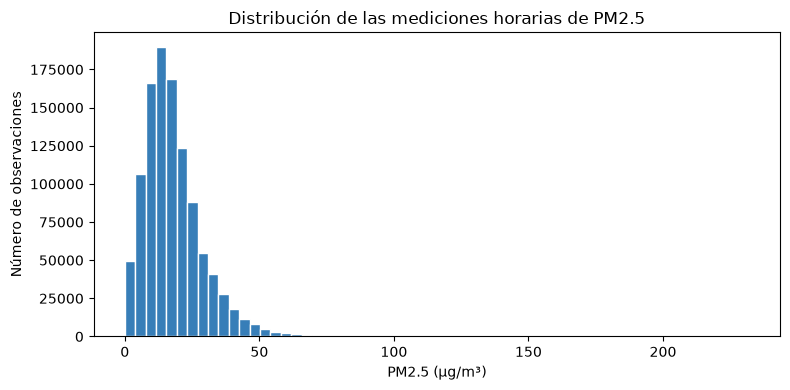

In [11]:
observed['pm25'].plot.hist(bins=60, figsize=(8, 4), color='#377eb8', edgecolor='white')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Número de observaciones')
plt.title('Distribución de las mediciones horarias de PM2.5')
plt.tight_layout()
plt.show()

La distribución es asimétrica a la derecha: la mediana es 16,00 µg/m³, la media 17,92 µg/m³ y el percentil 99 es 53,15 µg/m³. El criterio IQR marca 37.083 observaciones (3,47%) por encima de 41,98 µg/m³. Se conservan porque pueden corresponder a episodios reales y no a errores de medición. Los 2.747 ceros (0,26%) también se conservan: SIATA reporta mínimos horarios de 0,0 y no se identificó un código sentinela cero.

## 9. Patrones temporales

Se calculan promedios por hora del día y por mes. Estas agrupaciones describen patrones; no demuestran causalidad ni sustituyen la validación temporal del modelo.

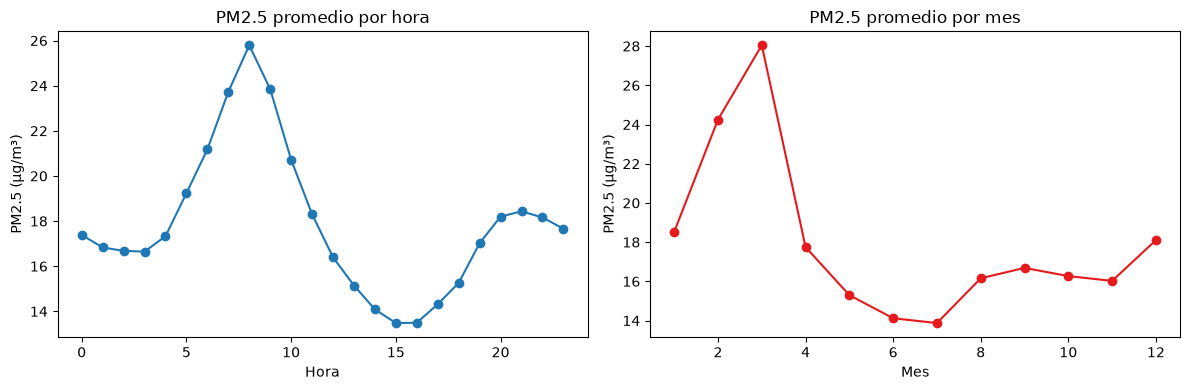

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
observed.groupby('hour')['pm25'].mean().plot(ax=axes[0], marker='o')
axes[0].set(title='PM2.5 promedio por hora', xlabel='Hora', ylabel='PM2.5 (µg/m³)')
observed.groupby('month')['pm25'].mean().plot(ax=axes[1], marker='o', color='#e41a1c')
axes[1].set(title='PM2.5 promedio por mes', xlabel='Mes', ylabel='PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

El promedio horario alcanza su máximo a las 08:00 (25,79 µg/m³) y su mínimo a las 15:00 (13,48 µg/m³). Por mes, marzo presenta el mayor promedio (28,05 µg/m³) y julio el menor (13,87 µg/m³). Estos patrones justifican evaluar hora y mes como predictores, pero describen asociación temporal y no causalidad.

## 10. Diferencias entre estaciones

Se comparan conteo, media y mediana dentro de la misma ventana temporal. La estación identifica el lugar de medición y puede capturar diferencias espaciales, de entorno y de exposición a fuentes locales.

,count,mean,median
station_id,,,
BAR-TORR,65332,12.67,10.59
COP-CVID,67765,14.27,12.73
BEL-FEVE,66798,14.95,13.21
MED-SCRI,66863,15.84,14.51
ENV-HOSP,67577,16.00,14.31
MED-TESO,66856,16.38,14.72
SAB-RAME,64985,17.13,15.45
MED-VILL,66415,17.30,15.59
EST-HOSP,68314,17.53,16.00


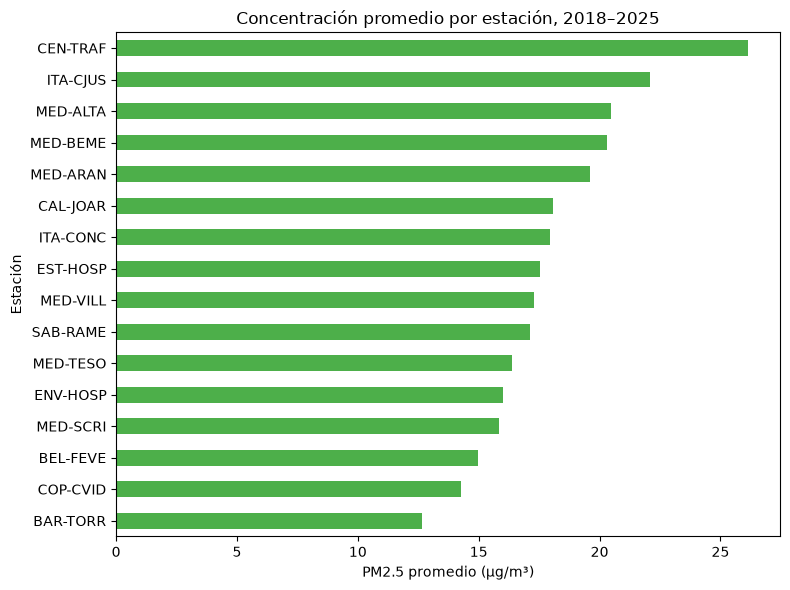

In [13]:
station_summary = observed.groupby('station_id')['pm25'].agg(['count', 'mean', 'median']).sort_values('mean')
display(station_summary.round(2))
station_summary['mean'].plot.barh(figsize=(8, 6), color='#4daf4a')
plt.xlabel('PM2.5 promedio (µg/m³)')
plt.ylabel('Estación')
plt.title('Concentración promedio por estación, 2018–2025')
plt.tight_layout()
plt.show()

CEN-TRAF presenta el promedio más alto (26,16 µg/m³) y BAR-TORR el más bajo (12,67 µg/m³). La diferencia confirma que `station_id` contiene información relevante. No implica que la ubicación sea la causa única: la emisión local, meteorología y tipo de entorno no se modelan en esta entrega.

## 11. Relación entre la medición actual y el target

Para evaluar si el forecasting a una hora tiene señal útil, se compara `pm25(t)` con `pm25(t+1)`. Esta relación es descriptiva y también define un baseline de persistencia: predecir que la siguiente hora será igual a la actual.

Correlación PM2.5(t) vs PM2.5(t+1): 0.804
MAE del baseline de persistencia: 4.978 µg/m³


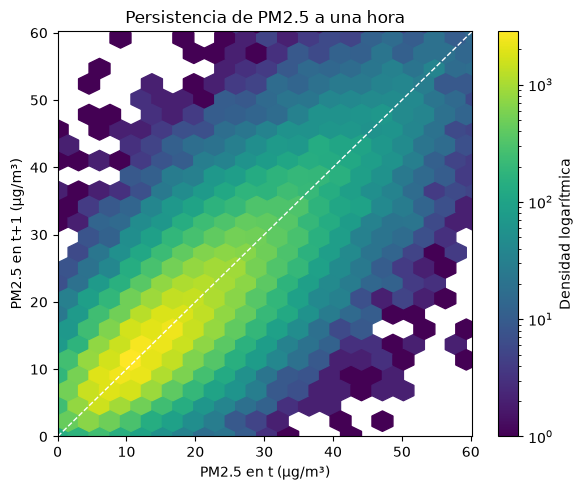

In [14]:
persistence_correlation = eligible['pm25'].corr(eligible['pm25_t_plus_1'])
persistence_mae = (eligible['pm25_t_plus_1'] - eligible['pm25']).abs().mean()
print('Correlación PM2.5(t) vs PM2.5(t+1):', round(persistence_correlation, 3))
print('MAE del baseline de persistencia:', round(persistence_mae, 3), 'µg/m³')

plot_sample = eligible.sample(n=min(100_000, len(eligible)), random_state=42)
plt.figure(figsize=(6, 5))
plt.hexbin(plot_sample['pm25'], plot_sample['pm25_t_plus_1'], gridsize=55, bins='log', mincnt=1, cmap='viridis')
limit = plot_sample[['pm25', 'pm25_t_plus_1']].quantile(0.995).max()
plt.plot([0, limit], [0, limit], '--', color='white', linewidth=1)
plt.xlim(0, limit)
plt.ylim(0, limit)
plt.xlabel('PM2.5 en t (µg/m³)')
plt.ylabel('PM2.5 en t+1 (µg/m³)')
plt.title('Persistencia de PM2.5 a una hora')
plt.colorbar(label='Densidad logarítmica')
plt.tight_layout()
plt.show()

La correlación de 0,804 muestra una asociación temporal fuerte entre horas consecutivas y respalda la viabilidad del problema. El baseline de persistencia obtiene MAE de 4,98 µg/m³ sobre todos los pares disponibles. Esto no es todavía el resultado de un modelo: en la Entrega 2 cualquier modelo deberá compararse con este baseline sobre un periodo de prueba futuro.

## 12. Hallazgos principales

Los tres hallazgos más útiles para el short paper son:

1. **Suficiencia y cobertura:** 16 estaciones alcanzan entre 92,67% y 97,41% de cobertura en 2018–2025; después de construir el target quedan 1.050.341 pares horarios utilizables.
2. **Estructura temporal:** el promedio es máximo a las 08:00 (25,79 µg/m³) y mínimo a las 15:00 (13,48 µg/m³); marzo tiene el mayor promedio mensual (28,05 µg/m³).
3. **Señal predictiva inicial:** `pm25(t)` y `pm25(t+1)` presentan correlación 0,804; el baseline de persistencia tiene MAE de 4,98 µg/m³.

## 13. Limitaciones

- La red cambió durante el histórico: existen 33 estaciones y 30 variantes de schema.
- La ventana y el umbral de cobertura reducen el análisis a 16 estaciones; los resultados no representan por igual toda la historia de la red.
- Los faltantes no se imputaron; la tabla supervisada excluye pares sin medición actual o siguiente.
- Los ceros y valores extremos se conservaron porque no hay evidencia suficiente para eliminarlos.
- La zona horaria explícita no aparece en los metadatos consultados.
- Solo se usan PM2.5 y variables temporales; no se atribuyen los patrones a causas meteorológicas o de emisión.

## 14. Implicaciones para la pregunta de investigación

Los datos permiten formular empíricamente un problema supervisado de regresión para predecir `pm25_t_plus_1`. La cobertura, el volumen de pares válidos y la asociación entre horas consecutivas indican que el modelado es viable. La Entrega 1 no demuestra todavía que un modelo supere el baseline; esa comparación corresponde a la metodología y evaluación de la Entrega 2.